In [79]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import os
import logging
import h5py
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
import healpy as hp
from itertools import product

from mlpng.utils import (
    setup_logging,
    plot_cl_alm,
    plot_predictions,
    plot_histogram,
    plot_elsner_comp,
    save_data,
    remove_mono_dipole,
    # pol_str,
)
from mlpng.generator import Generator
from mlpng.utils.utils import print_errors

logger = setup_logging(__name__, level=logging.DEBUG)

mpi_comm = None

## Setup

In [ ]:
generator = Generator(
    [
        "settings/n128.json",
        "--nsims",
        "10",
        "--narray",
        "1",
        # "--fnl_range",
        # "-1000",
        # "1000",
        "--pols",
        "T",
        "--shape",
        "equilateral",
        # "--no-noise",
        "--mc_steps",
        "100",
        # "--nside",
        # "128",
        # "--lmax",
        # "383",
    ]
)

# check if we actually need to run / clean files
# generator.check_existing_data_file()

# generator.run()

18-Feb-25 14:17:32 - mlpng.core - INFO - Parsing CLI args: ['settings/n128.json', '--nsims', '10', '--narray', '1', '--fnl_range', '-1000', '1000', '--pols', 'T', '--shape', 'equilateral', '--mc_steps', '100']
18-Feb-25 14:17:32 - mlpng.core - INFO - Loading settings from file 'settings/n128.json'
18-Feb-25 14:17:32 - mlpng.core - DEBUG - Forcing setting 'nsims' to 10 due to CLI
18-Feb-25 14:17:32 - mlpng.core - DEBUG - Forcing setting 'narray' to 1 due to CLI
18-Feb-25 14:17:32 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-1000, 1000] due to CLI
18-Feb-25 14:17:32 - mlpng.core - DEBUG - Forcing setting 'pols' to ['T'] due to CLI
18-Feb-25 14:17:32 - mlpng.core - DEBUG - Forcing setting 'shape' to equilateral due to CLI
18-Feb-25 14:17:32 - mlpng.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.66, 'As': 2.1056e-09, 'ns': 0.9665, 'ombh2': 0.02242, 'omch2': 0.11933, 'tau': 0.0561, 'pivot_scalar': 0.05} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar'

In [ ]:
pol_idxs = generator.pol_idxs()

alm_l = generator.generate_alm()
# alm_nl = generator.generate_alm_nl(alm_l)
alm_nl = generator.generate_alm_nl_shape(alm_l)
fnls = generator.rng.uniform(
    generator.fnl_min, generator.fnl_max, (generator.nsims, generator.ndups, 1)
)

# Add the duplicate dimension to the alms
alm_l = alm_l[:, None, pol_idxs]
alm_nl = alm_nl[:, None]

# finally combine into the full alms and remove the monopole and dipole terms
alms = alm_l + fnls[..., None] * alm_nl
alms = remove_mono_dipole(alms, inplace=True)
alms = np.ascontiguousarray(alms)

18-Feb-25 14:17:40 - mlpng.generator - INFO - Initializing KSW with 100 steps
18-Feb-25 14:22:40 - mlpng.generator - INFO - Saving KSW state to data/kswmc/l383_n128_equilateral_T_10x25_f1000.hdf5
18-Feb-25 14:22:40 - mlpng.generator - DEBUG - calculated fisher: 8.271344286862122e-05, std div: 109.95423235057413


alm_ng equilateral:   0%|          | 0/10 [00:00<?, ?it/s]

In [83]:
# make_alm_plots(generator, alm_l[:, 0], alm_nl[:, 0], alms[:, 0])

In [84]:
logger.info("Getting maps in nest ordering")
maps = np.zeros(generator.map_shape, dtype=generator.r_dtype)
for sim, dup in product(range(generator.nsims), range(generator.ndups)):
    rmap = hp.alm2map(alms[sim, dup], nside=generator.nside, pol=generator.use_pols)
    maps[sim, dup] = hp.reorder(rmap, r2n=True)

18-Feb-25 14:23:12 - __main__ - INFO - Getting maps in nest ordering


In [ ]:
# we go ahead and save some data so it can be freed, needed for nside > 512 to have good memory usage
sdata = {generator.shape: {}}
isdata = sdata[generator.shape]
if generator.save_alms:
    isdata["alm"] = alms.astype(generator.c_dtype)
    isdata["alm_l"] = alm_l.astype(generator.c_dtype)
    isdata["alm_nl"] = alm_nl.astype(generator.c_dtype)
# we transpose to get into a channels-last format, better for AI
isdata["map"] = np.transpose(maps, (0, 1, 3, 2)).astype(generator.r_dtype)
save_data(generator.file, sdata)
# del maps, alm_l, alm_nl  # actually force the garbage collection

18-Feb-25 14:23:13 - mlpng.utils.utils - INFO - Saving data to 'data/data/l383_n128_equilateral_T_10x25_f1000.hdf5'
18-Feb-25 14:23:13 - mlpng.utils.utils - DEBUG - alm: Processing key
18-Feb-25 14:23:13 - mlpng.utils.utils - DEBUG - alm: Processing ndarray
18-Feb-25 14:23:13 - mlpng.utils.utils - DEBUG - alm: Creating new dataset
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - alm_l: Processing key
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - alm_l: Processing ndarray
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - alm_l: Creating new dataset
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - alm_nl: Processing key
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - alm_nl: Processing ndarray
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - alm_nl: Creating new dataset
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - map: Processing key
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - map: Processing ndarray
18-Feb-25 14:23:14 - mlpng.utils.utils - DEBUG - map: Creating new dataset


In [86]:
logger.info("Starting lensing")
alm_lensed = generator.lens_alms(alms)

maps_lensed = np.zeros(generator.map_shape, dtype=generator.r_dtype)
for sim, dup in product(range(generator.nsims), range(generator.ndups)):
    rmap = hp.alm2map(
        alm_lensed[sim, dup], nside=generator.nside, pol=generator.use_pols
    )
    maps_lensed[sim, dup] = hp.reorder(rmap, r2n=True)

18-Feb-25 14:23:14 - __main__ - INFO - Starting lensing


In [87]:
# make_alm_plots(generator, alms=alm_lensed[:, 0, pol_idxs], lensed=True)

In [88]:
# note: we save as requested dtype but do calculations in complex128 since healpy needs it for alm2map
sdata = {}
sdata["fnl"] = fnls.astype(generator.r_dtype)
if generator.slurm.is_main:
    # only save 1 copy of the fnls, so only on main
    sdata["fisher_iso"] = generator.get_fisher_iso(False)
    if generator.lensing:
        sdata["fisher_iso_lensed"] = generator.get_fisher_iso(True)
if generator.lensing:
    if generator.save_alms:
        sdata["alm_lensed"] = alm_lensed[:, :, pol_idxs].astype(generator.c_dtype)

    sdata["map_lensed"] = np.transpose(
        maps_lensed[:, :, pol_idxs], (0, 1, 3, 2)
    ).astype(generator.r_dtype)
    # sdata["phi_map"] = phi_map.astype(generator.r_dtype)

save_data(generator.file, sdata)

18-Feb-25 14:26:45 - mlpng.generator - DEBUG - unlensed iso fisher: 8.355656e-05
18-Feb-25 14:30:12 - mlpng.generator - DEBUG - lensed iso fisher: 8.35566e-05
18-Feb-25 14:30:12 - mlpng.utils.utils - INFO - Saving data to 'data/data/l383_n128_equilateral_T_10x25_f1000.hdf5'
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fnl: Processing key
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fnl: Processing ndarray
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fnl: Creating new dataset
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fisher_iso: Processing key
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fisher_iso: Processing ndarray
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fisher_iso: Creating new dataset
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fisher_iso_lensed: Processing key
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fisher_iso_lensed: Processing ndarray
18-Feb-25 14:30:12 - mlpng.utils.utils - DEBUG - fisher_iso_lensed: Creating new dataset
18-Feb-25 1

## Alm

(10, 1, 1, 73920) (10, 1, 1, 73920) (10, 25, 1, 73920)


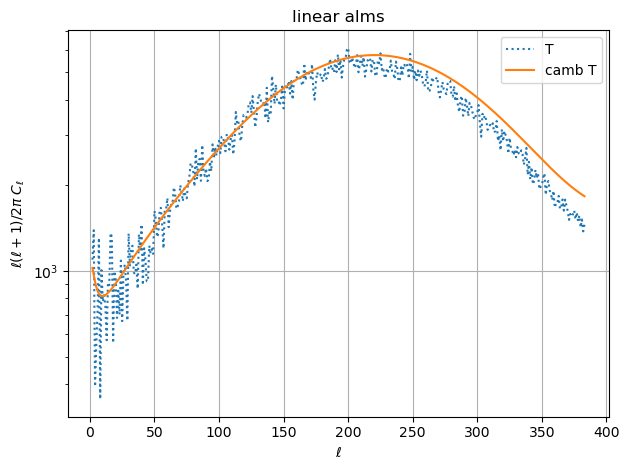

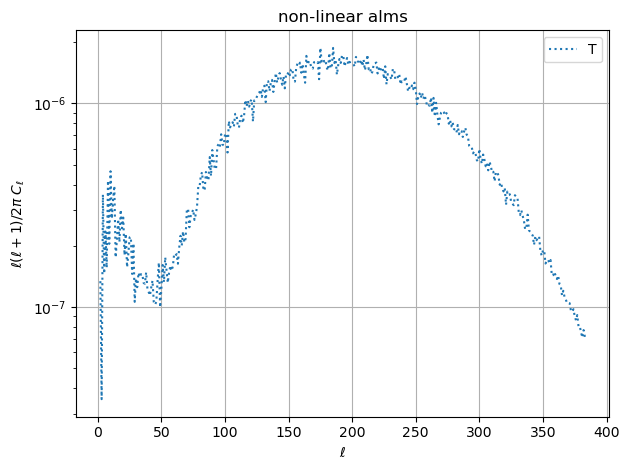

In [89]:
print(alm_l.shape, alm_nl.shape, alms.shape)
plot_cl_alm(
    generator,
    alm_l[0, 0],
    title="linear alms",
    # labels=plt_labels,
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
)

ells = np.arange(generator.nell)
scale = (ells * (ells + 1)) / (2 * np.pi)

plot_cl_alm(
    generator,
    alm_nl[0, 0],
    title="non-linear alms",
    plot_camb=False,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
    scale=True,
)

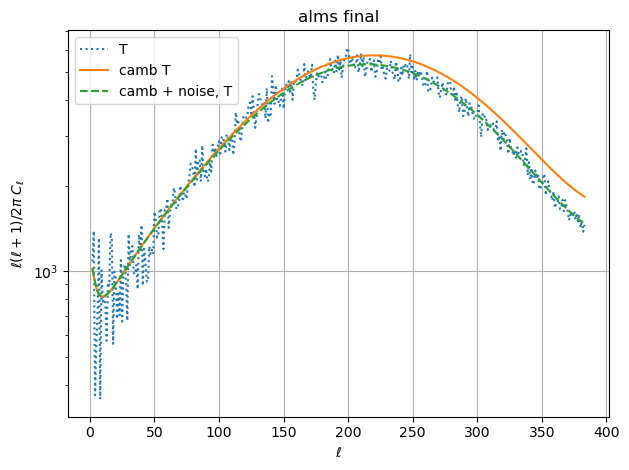

In [90]:
plot_cl_alm(
    generator,
    alms[0, 0],
    title="alms final",
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=True,
    show=True,
)

18-Feb-25 14:30:15 - mlpng.utils.plots - INFO - Mean ratio of alm T: 129274.06746179298
18-Feb-25 14:30:15 - mlpng.utils.plots - INFO - Mean ratio of elsner T: 12745.108704410502


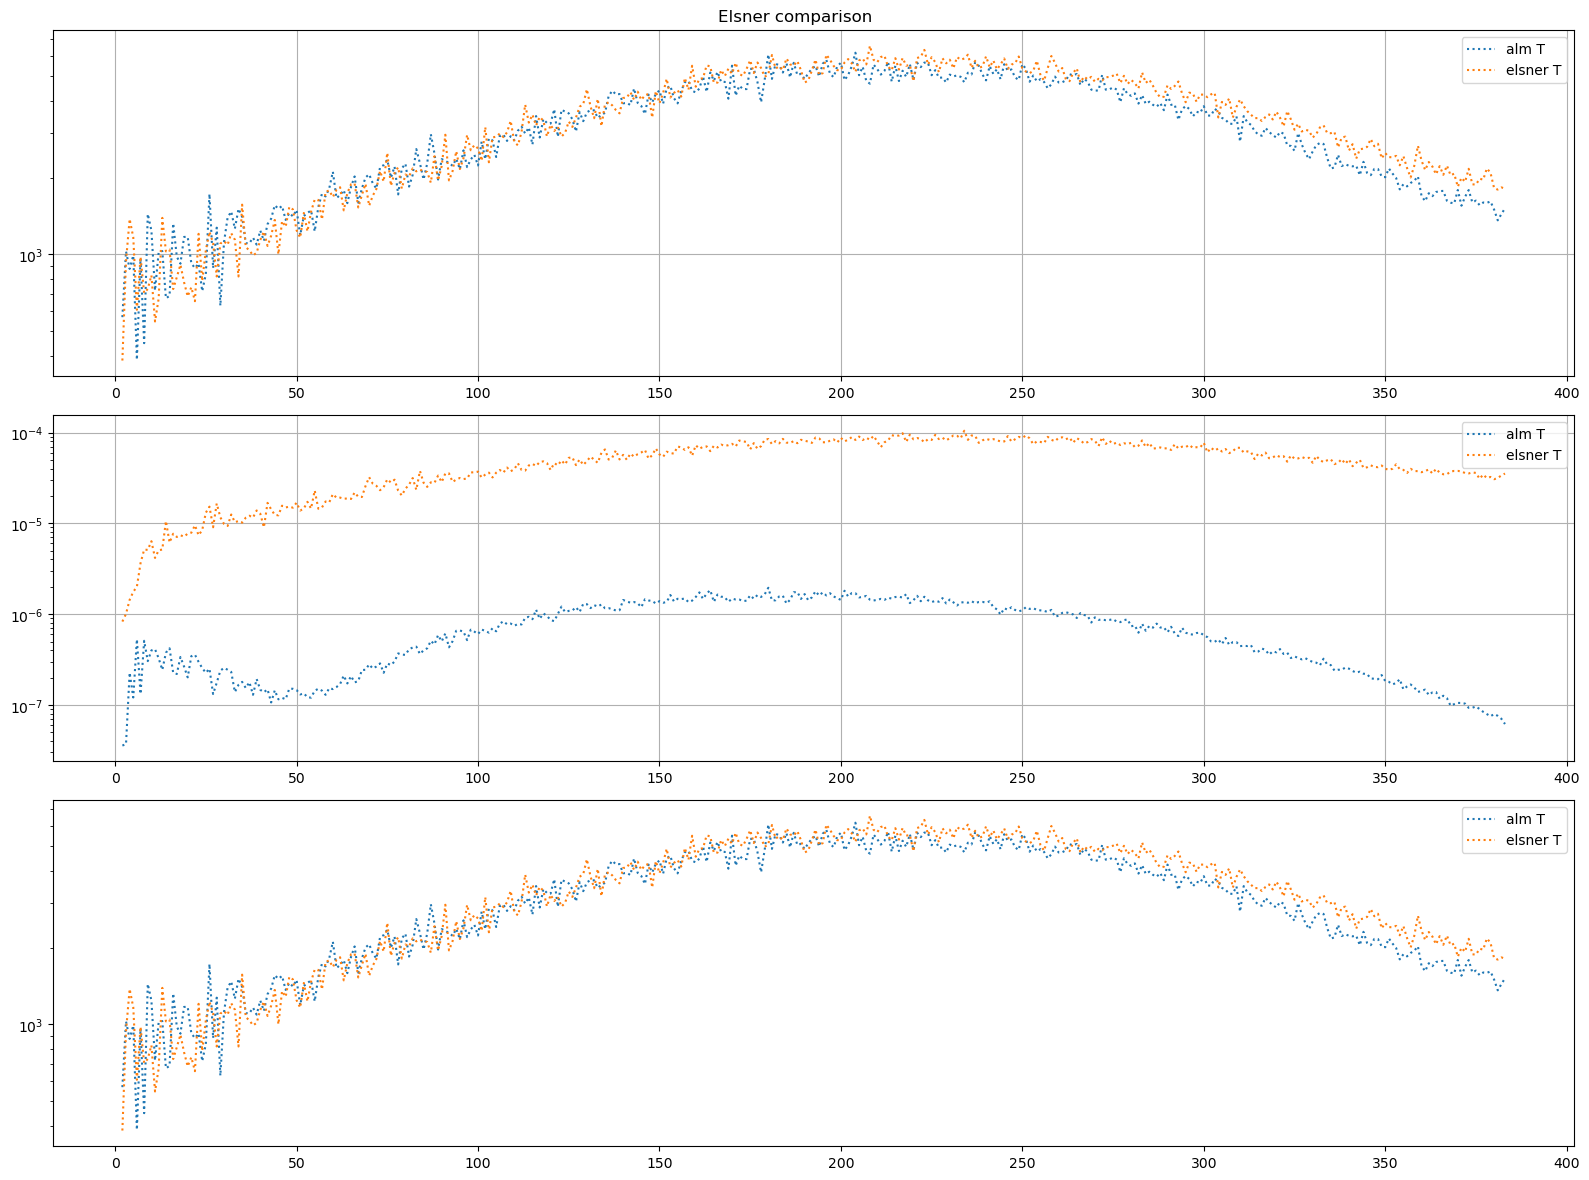

18-Feb-25 14:30:16 - mlpng.utils.plots - INFO - Mean ratio of alm T: 129274.06746179298
18-Feb-25 14:30:16 - mlpng.utils.plots - INFO - Mean ratio of elsner T: 12745.108704410502


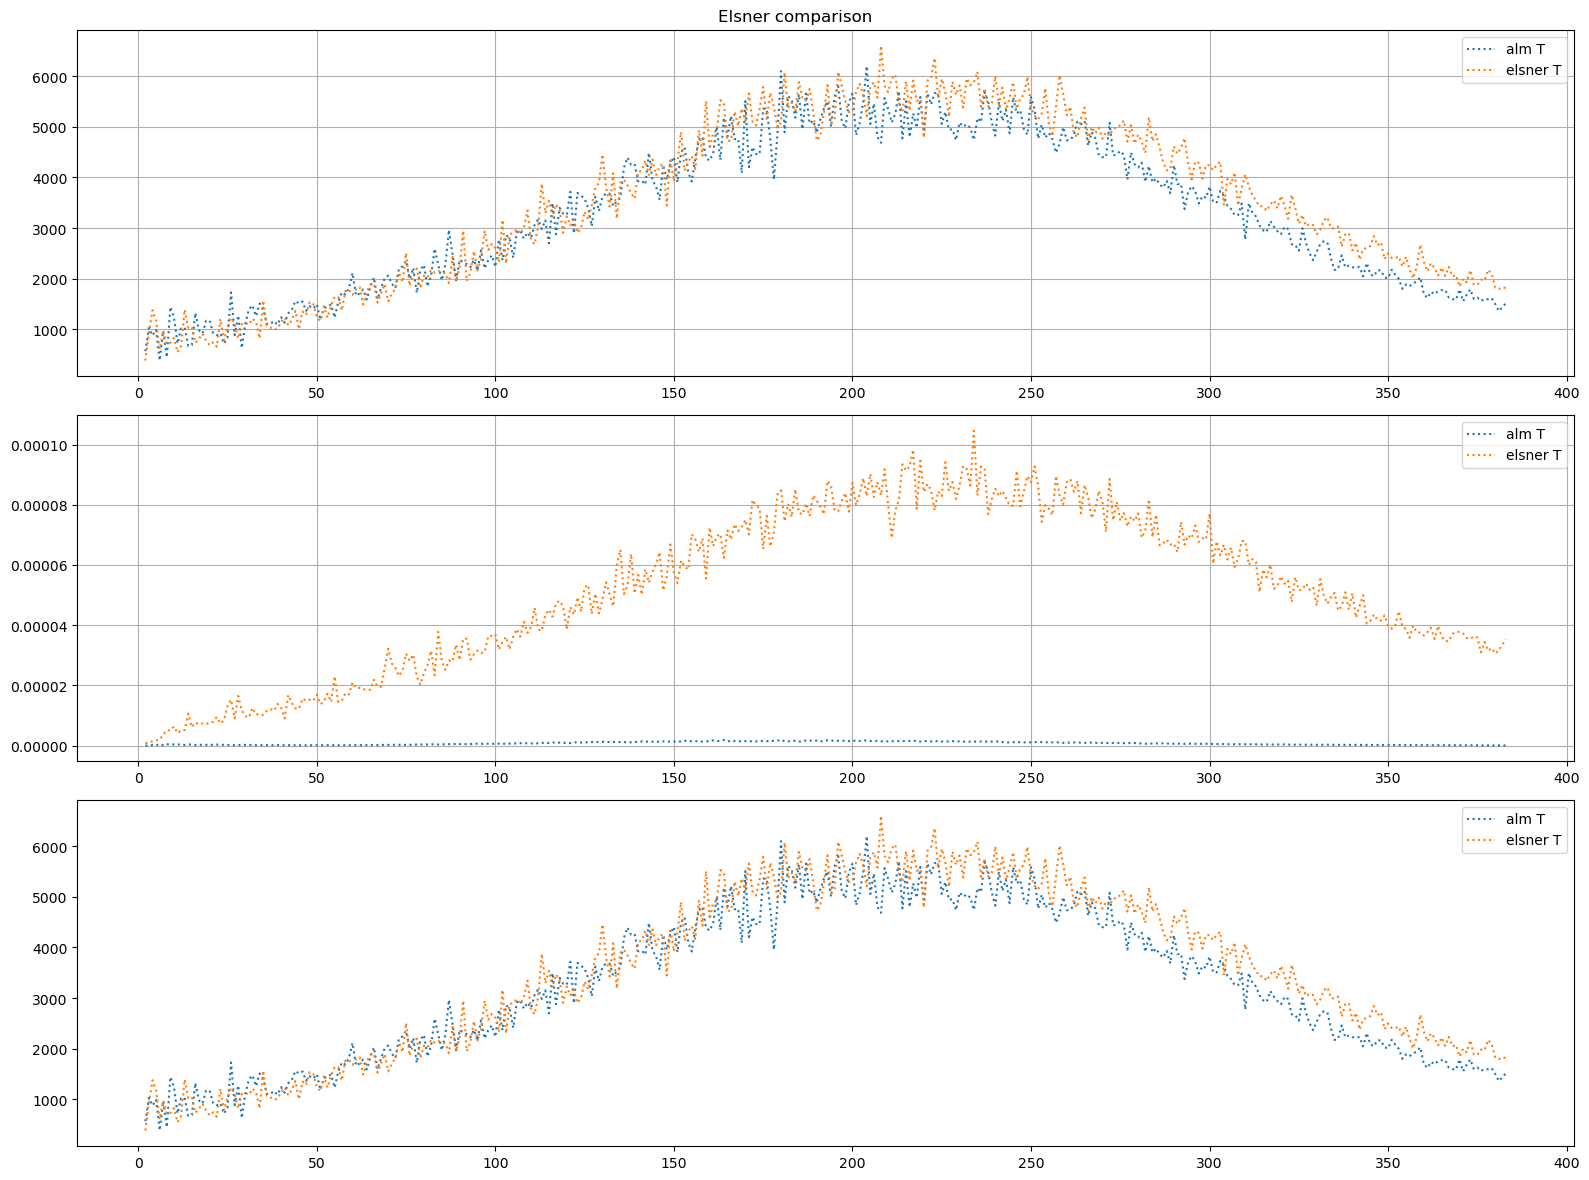

18-Feb-25 14:30:17 - mlpng.utils.plots - INFO - Mean ratio of alm T: 129274.06746179298
18-Feb-25 14:30:17 - mlpng.utils.plots - INFO - Mean ratio of elsner T: 12745.108704410502


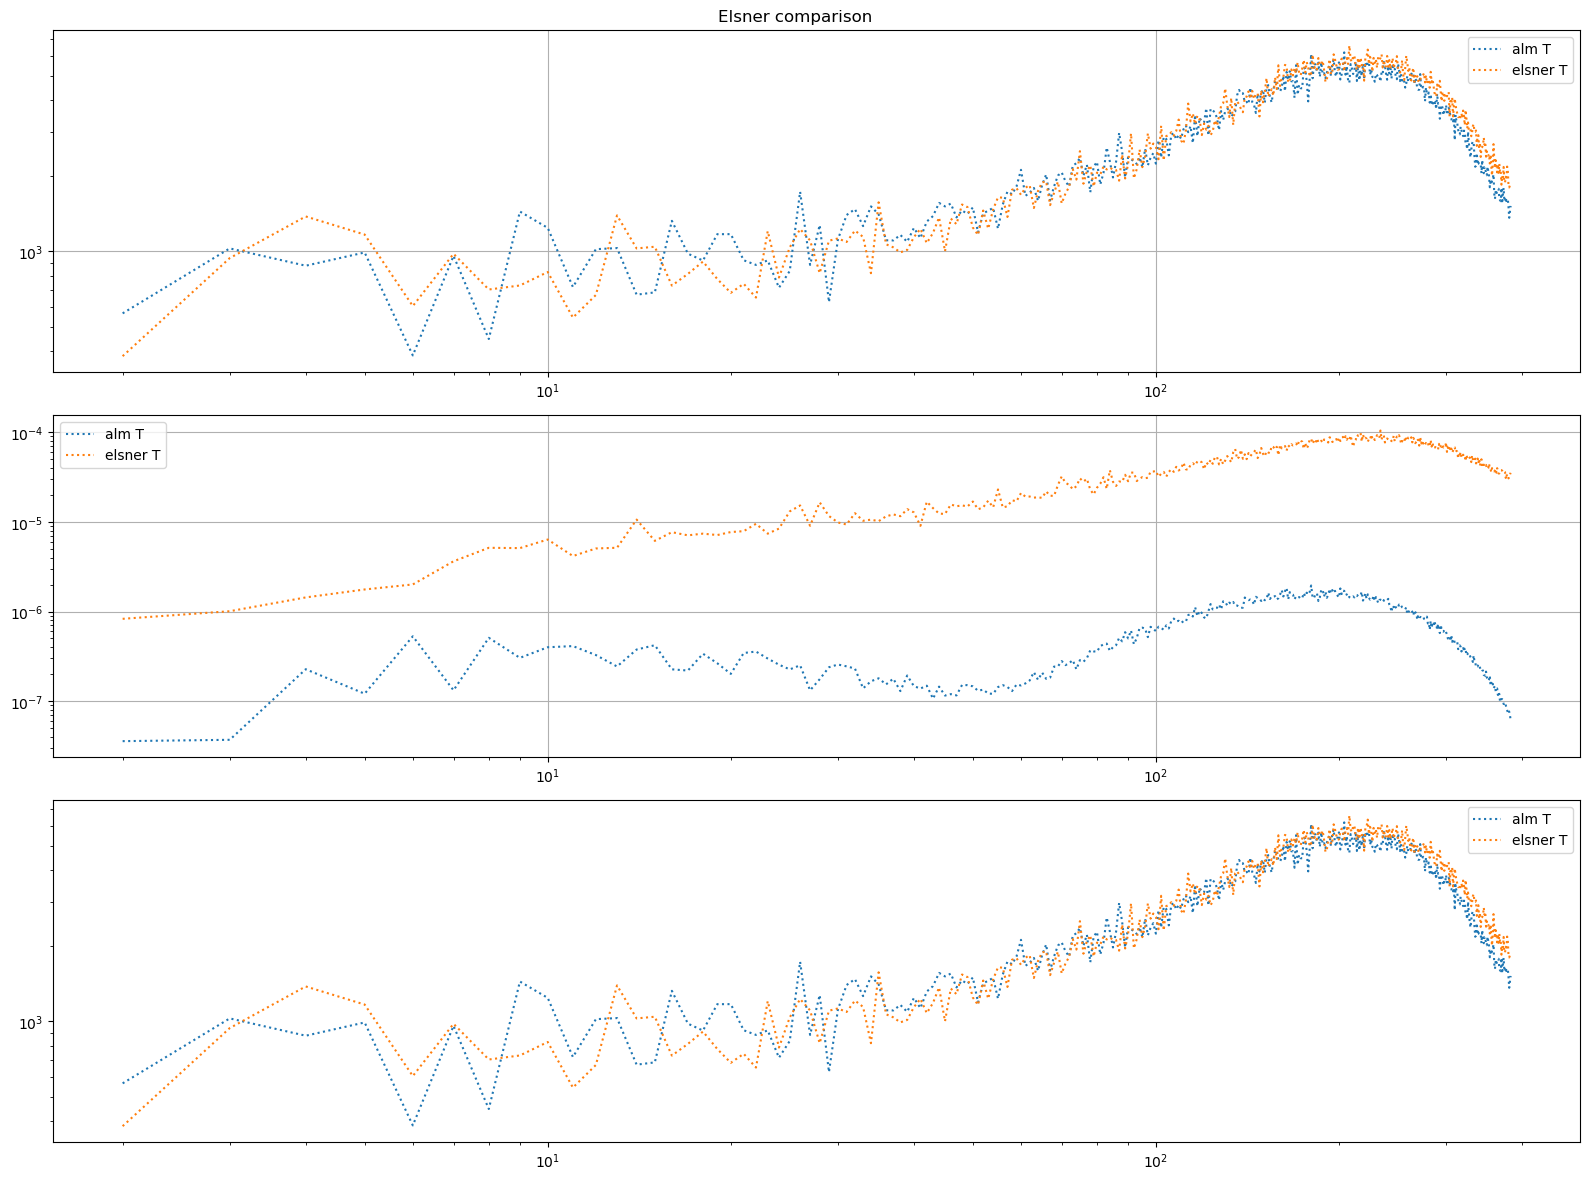

In [91]:
sim = generator.rng.integers(generator.nsims)
eidx = generator.rng.integers(1, 1001)
plot_elsner_comp(
    generator,
    alm_l[sim, 0],
    alm_nl[sim, 0],
    index=eidx,
    show=True,
    plot_func=plt.semilogy,
)
plot_elsner_comp(
    generator,
    alm_l[sim, 0],
    alm_nl[sim, 0],
    index=eidx,
    show=True,
    plot_func=plt.plot,
)
plot_elsner_comp(
    generator,
    alm_l[sim, 0],
    alm_nl[sim, 0],
    index=eidx,
    show=True,
    plot_func=plt.loglog,
)

18-Feb-25 14:30:18 - mlpng.utils.plots - DEBUG - Averaging 10 elsner sims, this will take a while


Averaging elsner sims:   0%|          | 0/10 [00:00<?, ?it/s]

18-Feb-25 14:30:23 - mlpng.utils.plots - INFO - Mean ratio of alm T: 128074.69225465943
18-Feb-25 14:30:23 - mlpng.utils.plots - INFO - Mean ratio of elsner T: 12726.479847793642


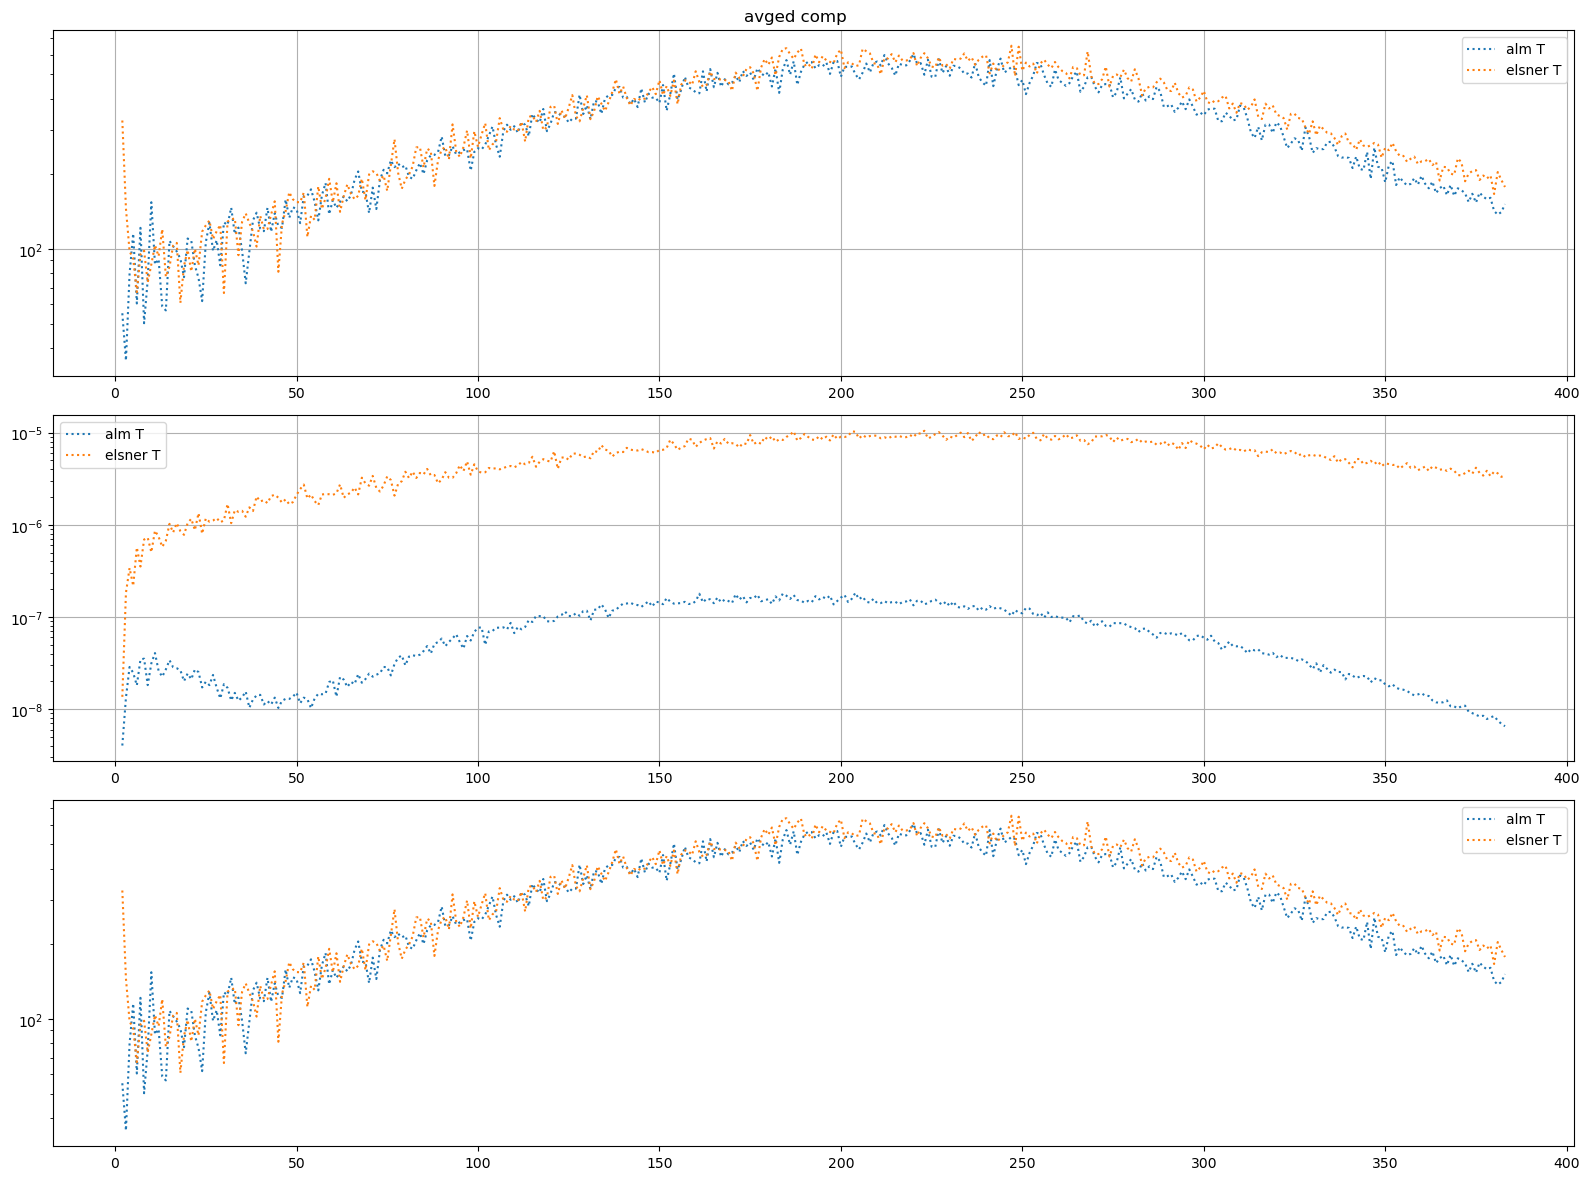

In [92]:
alm_l_avg = np.mean(alm_l[:, 0], axis=0)
alm_ng_avg = np.mean(alm_nl[:, 0], axis=0)

plot_elsner_comp(
    generator,
    alm_l_avg,
    alm_ng_avg,
    average=generator.nsims,
    title="avged comp",
    show=True,
    plot_func=plt.semilogy,
)

## Estimator

In [93]:
mpi_size = 1

# the KSW code requires the total_sims to be >= mpi_size
# best usage would have total_sims % mpi_size == 0, but not required
assert (
    generator.num_estimates >= mpi_size
), "total_sims < mpi_size, lower ntasks or increase sims"

logger.info(
    "Computing %s estimates in %.2f batches",
    generator.num_estimates,
    generator.num_estimates / mpi_size,
)
if generator.num_estimates % mpi_size != 0:
    logger.warning(
        "num_estimates is not divisible by mpi_size, "
        "this will lead to uneven workloads."
    )

# The default theta_batch size is 25, which is really small, we want to increase it
theta_batch = int(np.floor(1.5 * generator.lmax + 1)) // mpi_size
logger.debug("Using theta_batch %s", theta_batch)

if generator.isotropic:
    with h5py.File(generator.file, "r", swmr=True, locking=False) as data:
        fisher = data["fisher_iso"][0]
else:
    logger.debug("Computing fisher")
    if os.path.exists(generator.mc_file):
        logger.info("Loading KSW state from %s", generator.mc_file)
        generator.ksw.start_from_read_state(generator.mc_file, comm=mpi_comm)
    else:
        alm_steps = generator.generate_alm(nsims=generator.mc_steps)

        logger.info("Initializing KSW with %s steps", generator.mc_steps)
        generator.ksw.step_batch(
            lambda i: generator.icov_func(alm_steps[i, generator.pol_idxs()]),
            range(generator.mc_steps),
            mpi_comm,
            theta_batch=theta_batch,
        )

        # save the mc state if we are using the mc file
        if generator.slurm.is_main:
            logger.info("Saving KSW state to %s", generator.mc_file)
            generator.ksw.write_state(generator.mc_file, comm=mpi_comm)

    fisher = generator.ksw.compute_fisher()

18-Feb-25 14:30:25 - __main__ - INFO - Computing 10 estimates in 10.00 batches
18-Feb-25 14:30:25 - __main__ - DEBUG - Using theta_batch 575


In [96]:
fisher = generator.ksw.compute_fisher_isotropic(generator.icov[0], comm=mpi_comm)
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

Fisher: 8.355615864275023e-05, standard deviation: 109.39834719871364


In [97]:
estimates, _, _, _ = generator.ksw.compute_estimate_batch(
    lambda idx: generator.icov_func(alms[idx, 0], generator.icov),
    range(generator.nsims),
    theta_batch=int(np.floor(1.5 * generator.lmax + 1)) // generator.slurm.n_cpus,
    fisher=fisher,
    lin_term=0,
)

fnl shape (10, 25, 1) estimates shape (10,) fisher 8.355616e-05
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - Standard deviation from fisher: 109.39834881649395, SEM: 34.594795452170665
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - Mean error: -53.70405595508885, Median error: -22.821568143537974
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - 60.0% (60.0, 70.0) are within 1 standard deviations
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - 100.0% (70.0, 100.0) are within 2 standard deviations
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 3 standard deviations
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 4 standard deviations
18-Feb-25 14:34:14 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 5 standard deviations


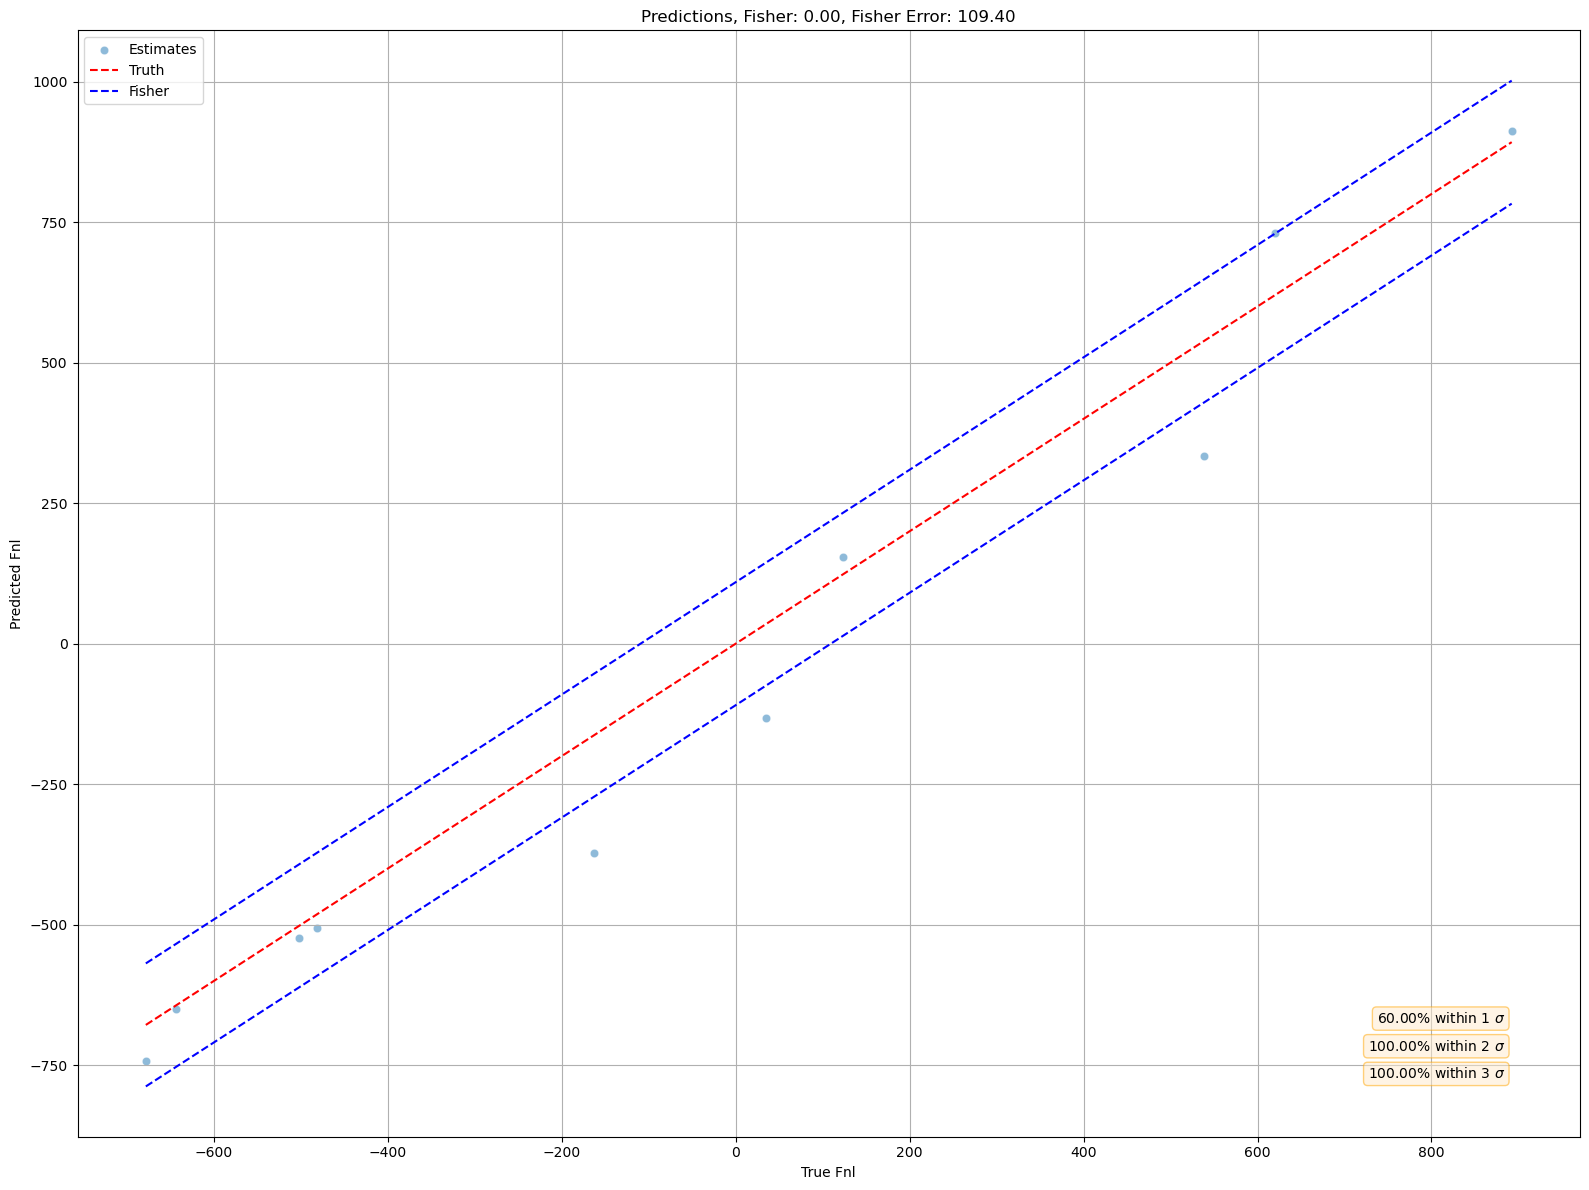

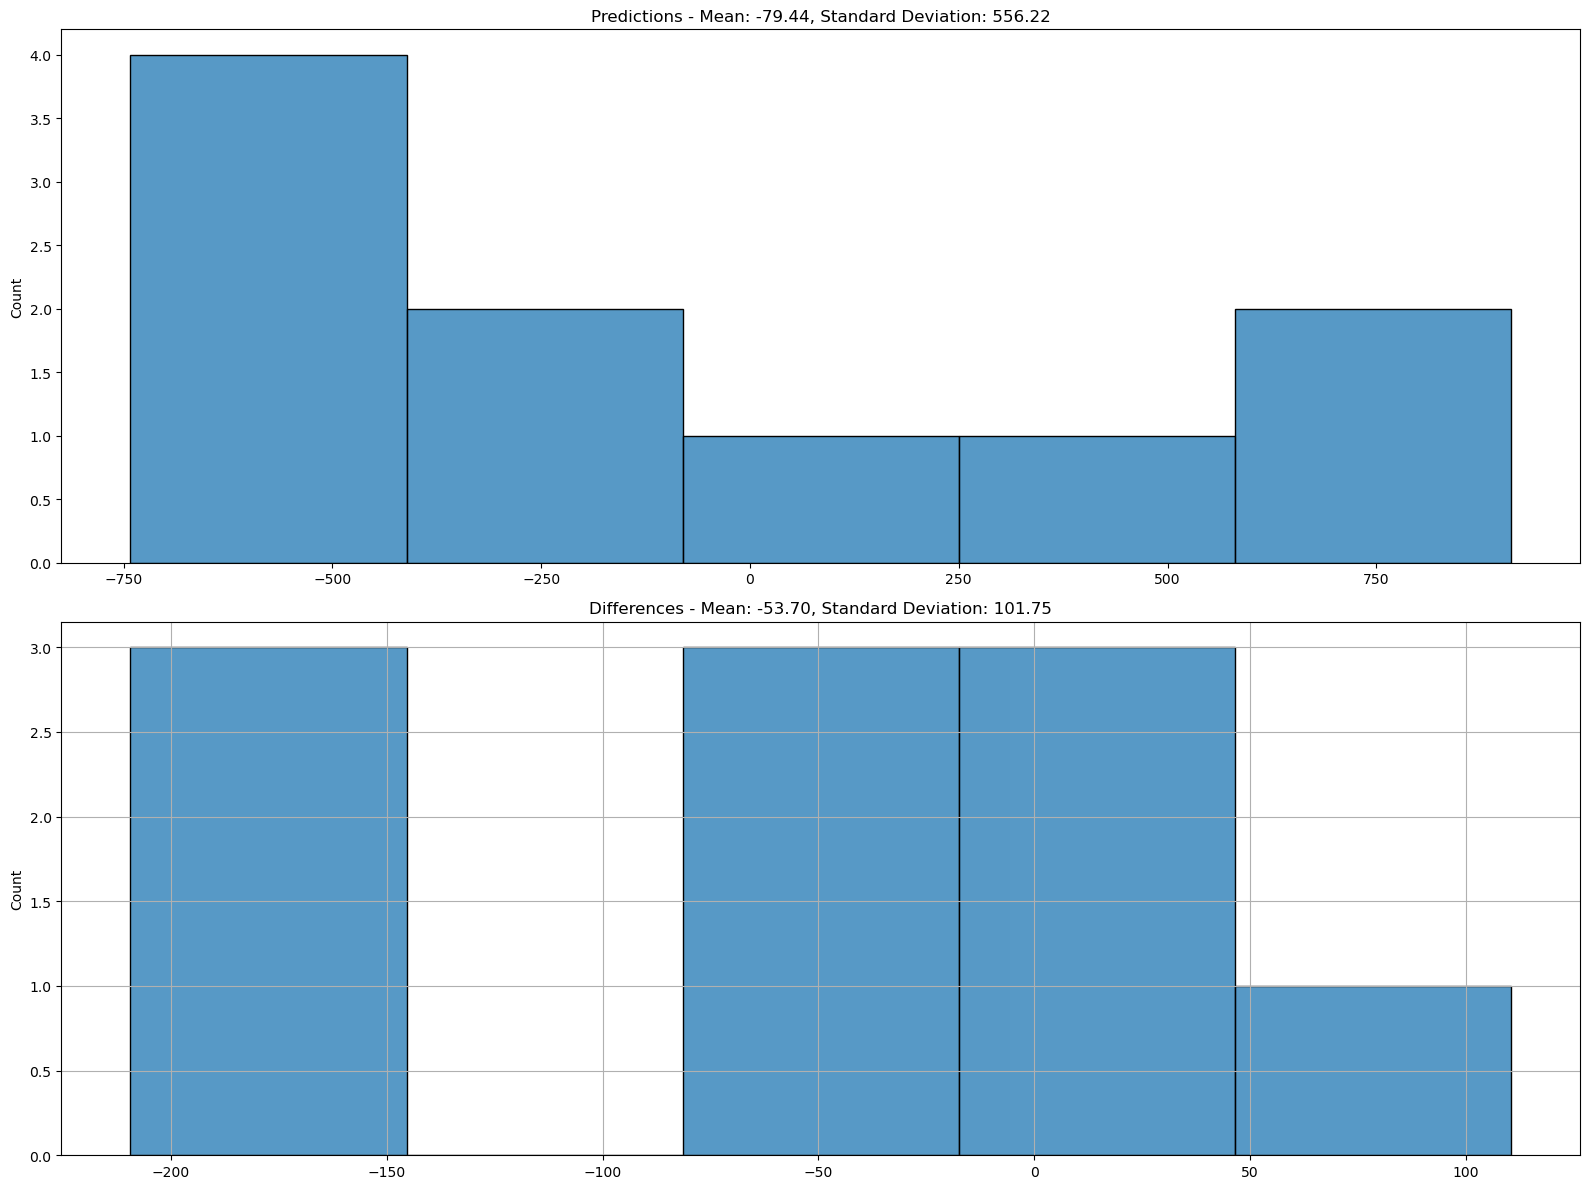

In [98]:
print("fnl shape", fnls.shape, "estimates shape", estimates.shape, "fisher", fisher)
fnls_flat = fnls[:, 0, 0]
print_errors(fnls_flat, estimates, fisher)
plot_predictions(fnls_flat, estimates, fisher=fisher, show=True)
plot_histogram(fnls_flat, estimates, show=True)

## Lensing

In [99]:
alm_lensed = generator.lens_alms(alms)

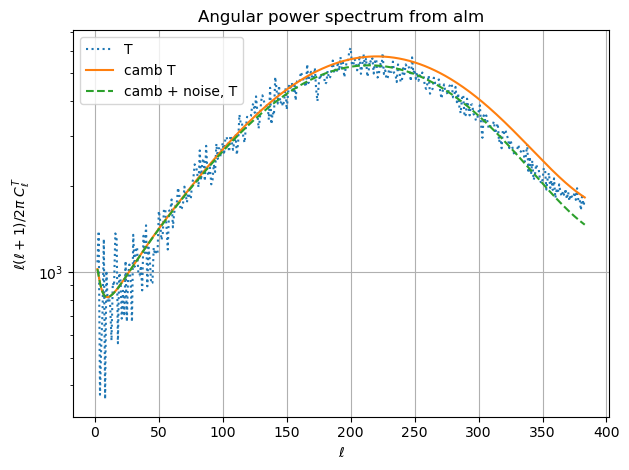

In [100]:
sim = 0
for i, pol in enumerate(generator.pol_idxs()):
    pstr = generator.pols[pol]

    ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
    plot_cl_alm(
        generator,
        alm_lensed[sim, i],
        # save_file=filebase,
        ylabel=ylabel,
        plot_camb=True,
        plot_noise=False,
        plot_full_camb=True,
        show=True,
        lmin=2,
    )

In [101]:
lens_estimates, _, _, _ = generator.ksw.compute_estimate_batch(
    lambda a: generator.icov_func(
        alm_lensed[a, 0, generator.pol_idxs(pretrimmed=True)]
    ),
    range(generator.nsims),
    theta_batch=int(np.floor(1.5 * generator.lmax + 1)) // generator.slurm.n_cpus,
    fisher=fisher,
    lin_term=0,
)

fnl shape (10, 25, 1) estimates shape (10,) fisher 8.355616e-05
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - Standard deviation from fisher: 109.39834881649395, SEM: 34.594795452170665
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - Mean error: -51.610139539622324, Median error: -34.87694588728829
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - 60.0% (60.0, 70.0) are within 1 standard deviations
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - 90.0% (70.0, 100.0) are within 2 standard deviations
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - 100.0% (90.0, 100.0) are within 3 standard deviations
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 4 standard deviations
18-Feb-25 14:34:40 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 5 standard deviations


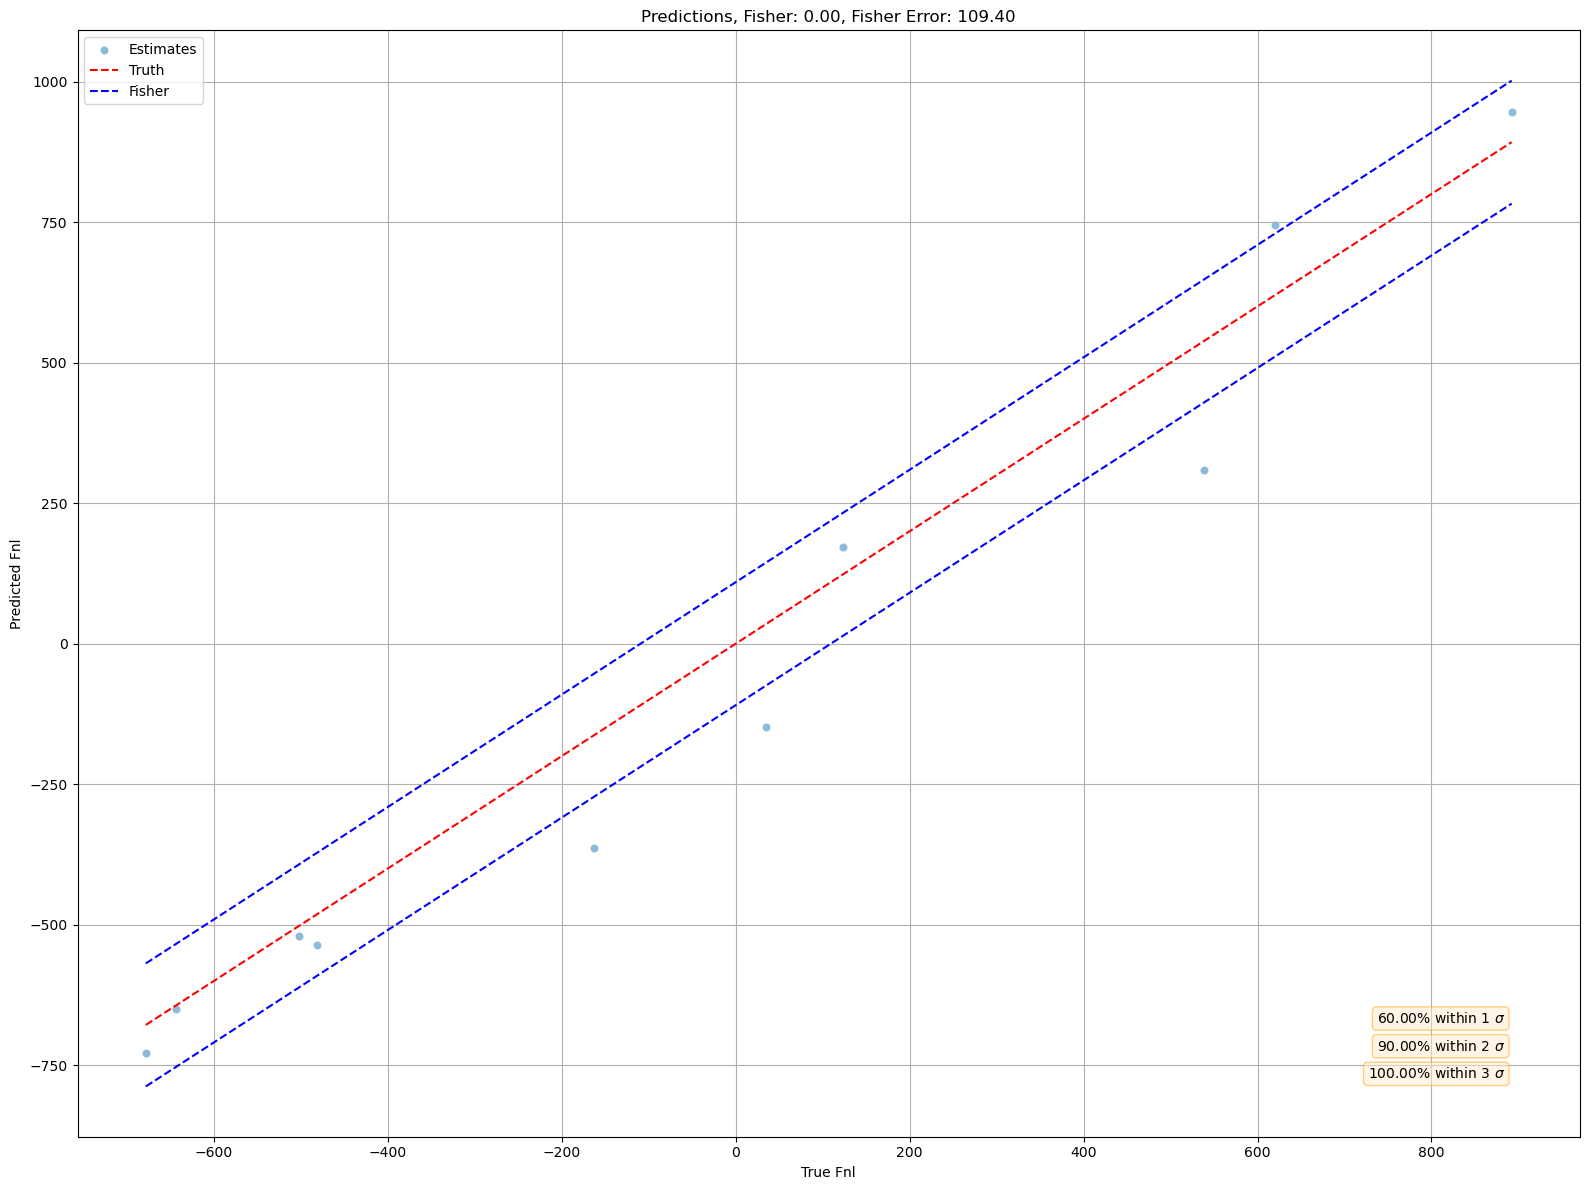

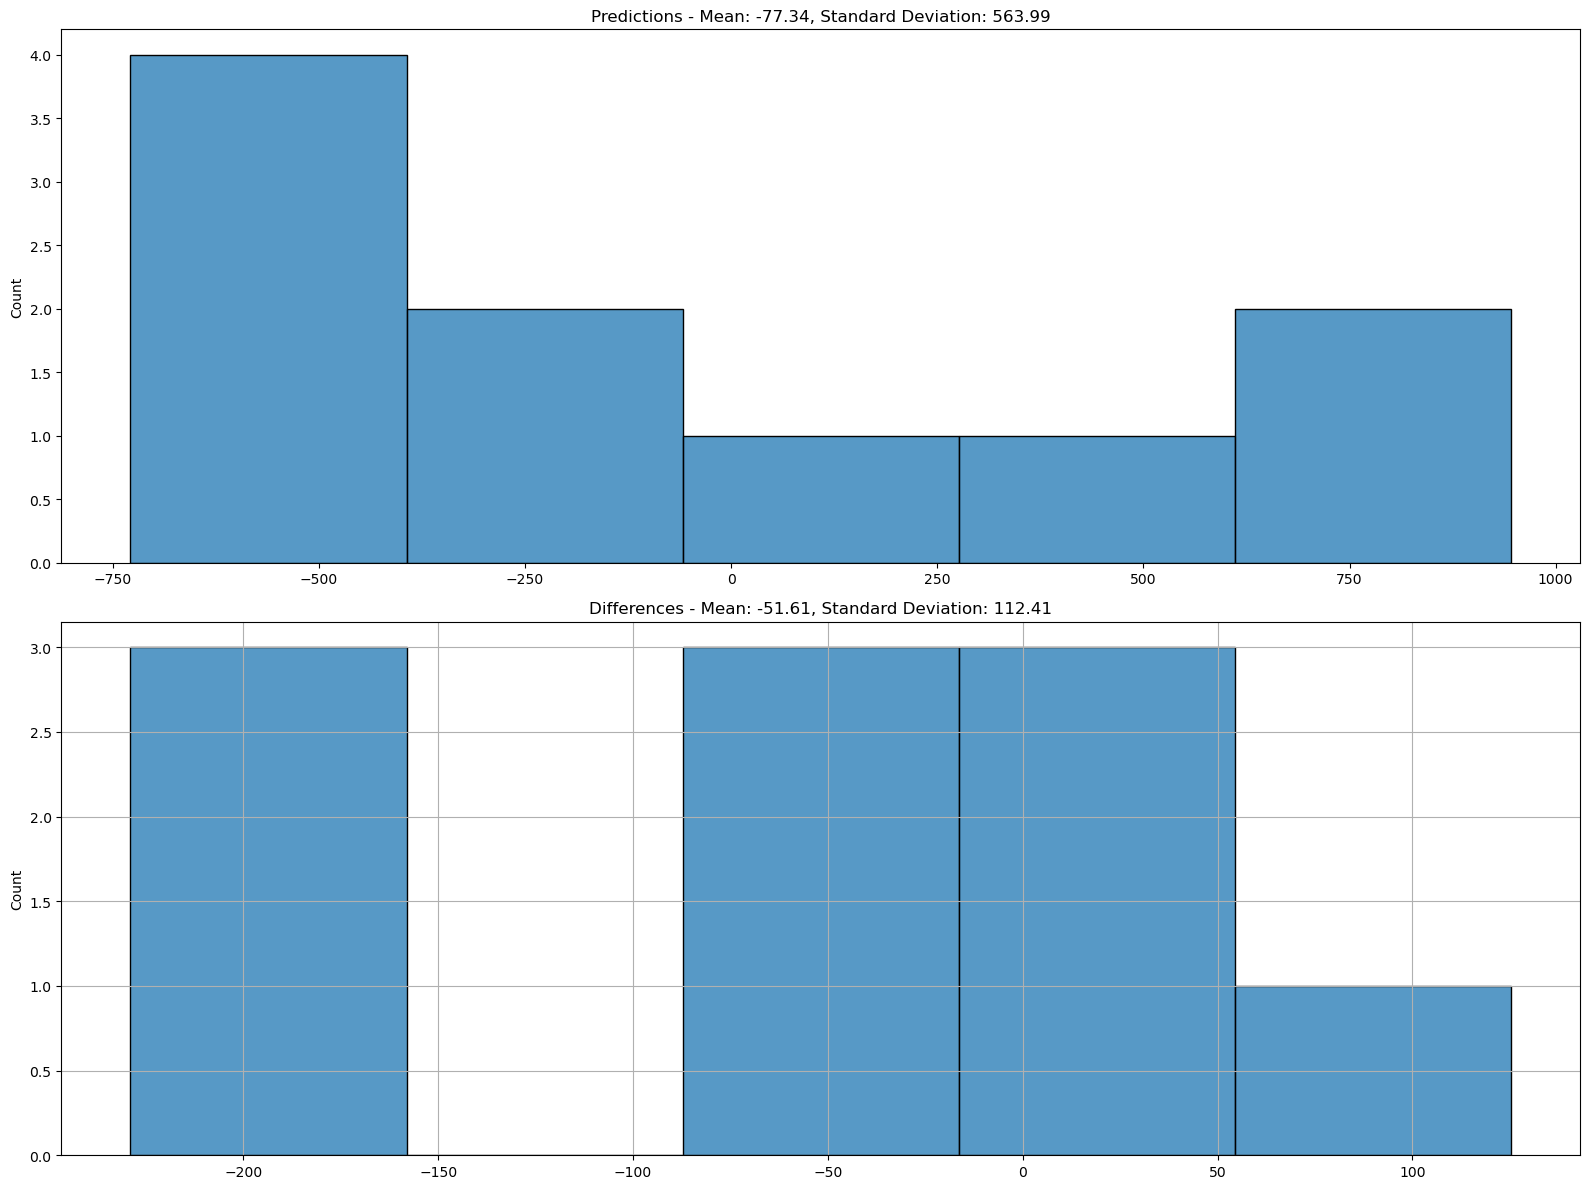

In [102]:
print(
    "fnl shape", fnls.shape, "estimates shape", lens_estimates.shape, "fisher", fisher
)
fnls_flat = fnls[:, 0, 0]
print_errors(fnls_flat, lens_estimates, fisher)
plot_predictions(fnls_flat, lens_estimates, fisher=fisher, show=True)
plot_histogram(fnls_flat, lens_estimates, show=True)